# Stacked matched panel DiD — full robustness menu

Every number in the manuscript's exhibits is regenerated or verified from the aggregate artifacts in `artifacts/`; no licensed microdata is used or required (see `DATA_ACCESS.md`).
Outputs are stored, so the notebooks render on GitHub without running. Rebuild with `python3 code/make_notebooks.py`.


## Setup


In [ ]:
import sys, runpy
sys.path.insert(0, "code"); import exhibits_lib as X
md = open("manuscript/PE_Labour_Adjustment_manuscript_2026-08-31.md", encoding="utf-8").read()
paper, appendix = X.split_document(md)
pool = X.load_pool("artifacts")
print("artifact pool loaded ·", len(pool), "quantized values")


artifact pool loaded · 58026 quantized values


## Event-study coefficients — level and state interaction
Stacked matched panel with unit (event×firm) and calendar-month fixed effects; event-clustered intervals. Reference quarter −1.


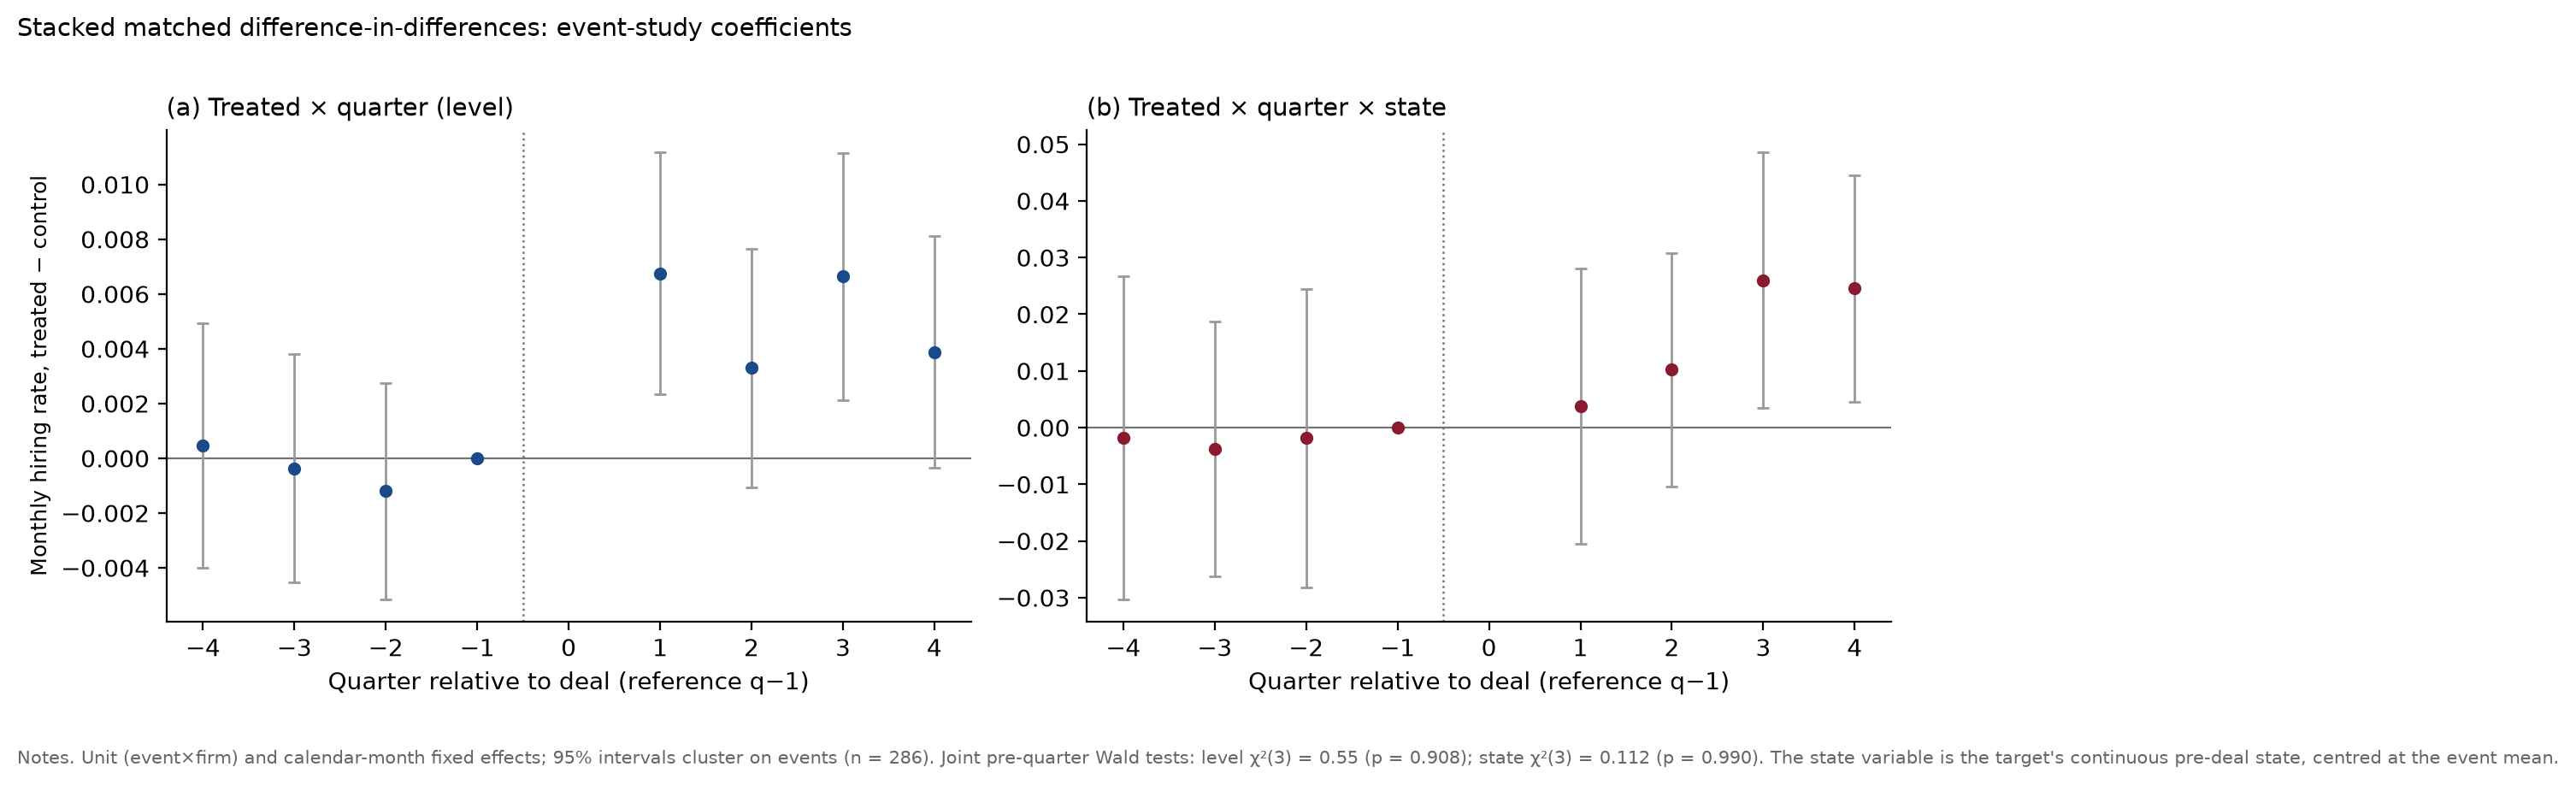

saved figure_did_eventstudy
saved figure_did_bystate


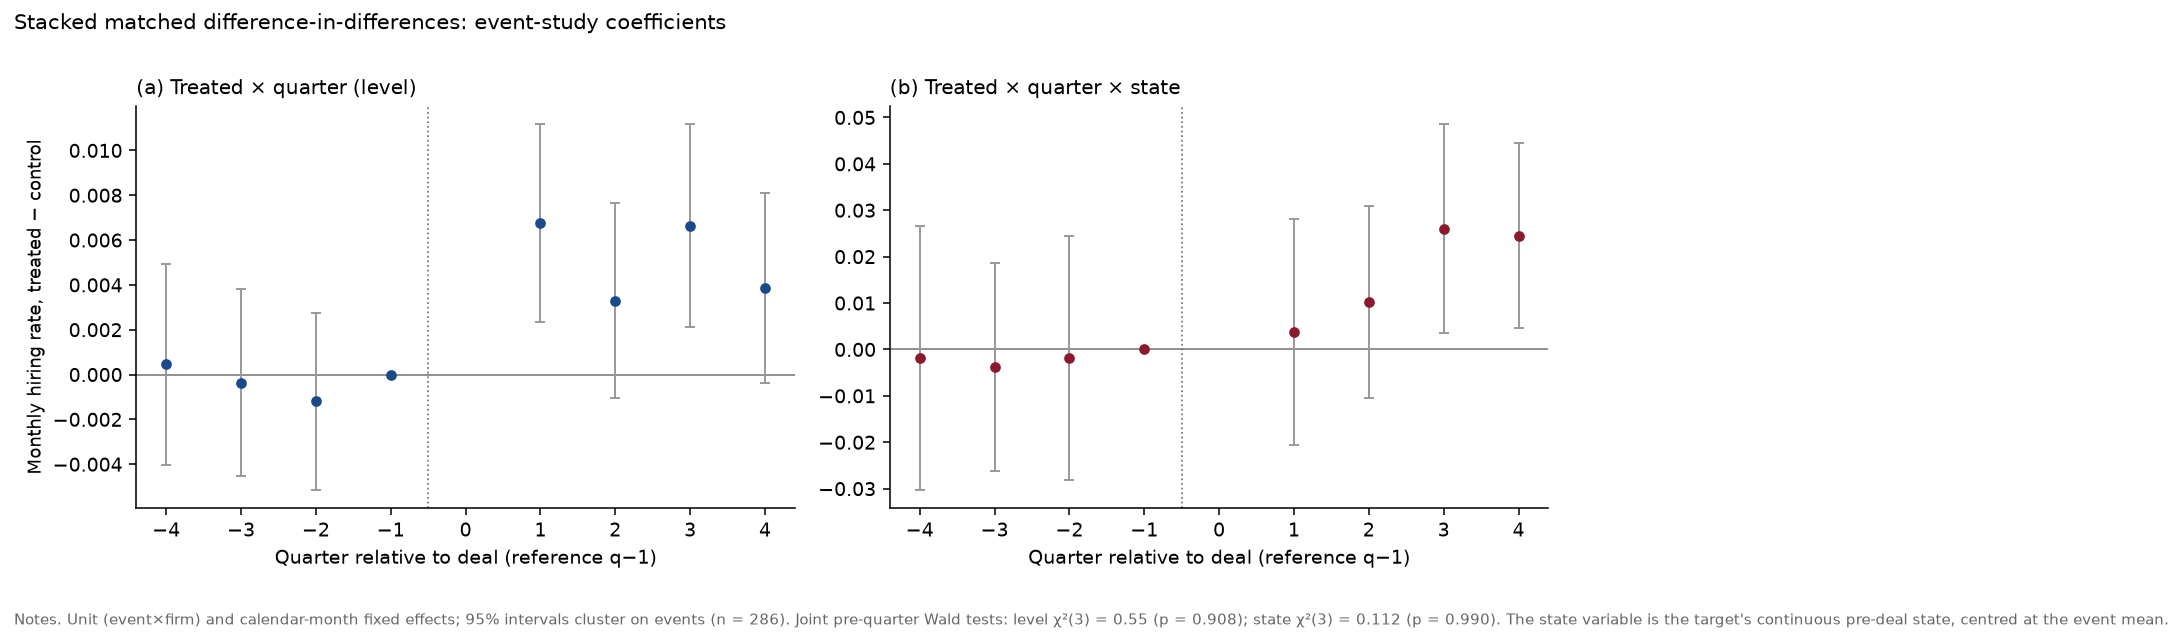

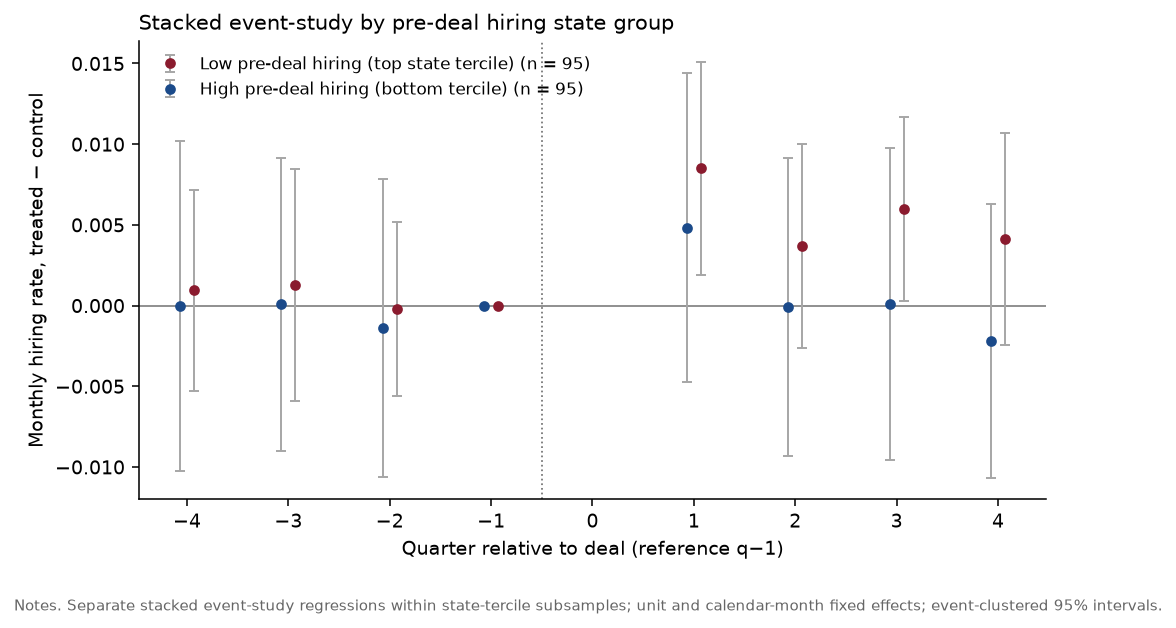

In [ ]:
runpy.run_path("code/build_figure_did.py", run_name="__main__")
_figs = [open("figures/figure_did_eventstudy.png", "rb").read()]


## Event-study by pre-deal state group


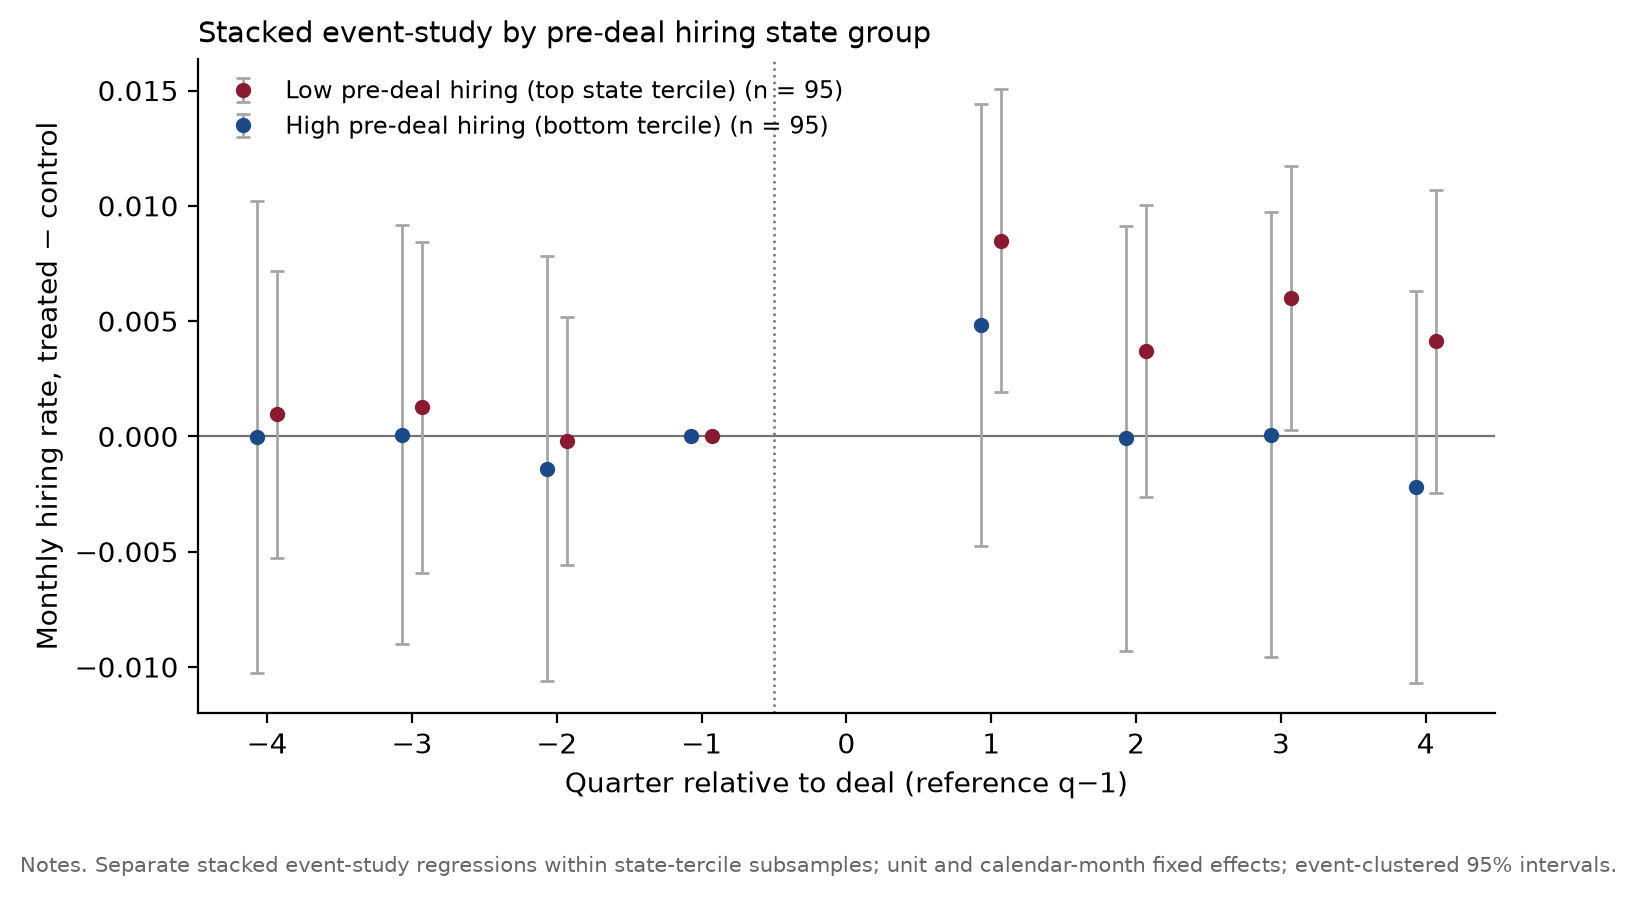

In [ ]:
_figs = [open("figures/figure_did_bystate.png", "rb").read()]


## Full statistics menu
All panels (outcome variants, state parametrisations, design comparison, specification variants, magnitudes, joint pre-trend Wald tests).


In [ ]:
runpy.run_path("code/make_did_results.py", run_name="__main__")
_md = open("did/DID_RESULTS.md", encoding="utf-8").read()


# Stacked matched panel DiD — full statistics menu (I75)

Design: 286 state-balanced matched sets stacked into an event×firm panel (1,545 units, 36,913 firm-months, 115 calendar months). Outcome: monthly worker-entry rate (entries / insured employment), untransformed. Fixed effects: unit and calendar month. SEs cluster on events. The state S is the target's continuous pre-deal state assigned to its matched set, centred at the event mean (-0.3517), so the Treated×Post coefficient is the effect at the mean state. Controls are never-treated, so the stacked design involves no treated-vs-treated comparisons.

## Panel A — headline DiD

| Coefficient | Estimate | 95% CI | t |
|---|---:|---:|---:|
| Treated × post (level model) | +0.0054 | [0.0028, 0.0081] | 3.98 |
| Treated × post (interaction model, at mean S) | +0.0055 | [0.0029, 0.0081] | 4.11 |
| Treated × post × S | +0.0179 | [0.0035, 0.0323] | 2.44 |

## Panel B — outcome variants (β1 at mean S / β2)

| Outcome | β1 | t | β2 | t | Rows |
|---|---:|---:|---:|---:|---:|
| Monthly hiring rate | +0.0055 | 4.11 | +0.0179 | 2.44 | 36,913 |
| log(1 + rate) | +0.0052 | 4.24 | +0.0161 | 2.45 | 36,913 |
| Any−entry indicator | +0.0702 | 6.11 | +0.1233 | 2.33 | 36,913 |
| Separation rate | −0.0000 | −0.00 | +0.0023 | 0.26 | 36,913 |
| Churn rate | +0.0055 | 2.51 | +0.0202 | 1.62 | 36,913 |

## Panel C — state parametrisations (β2 equivalents)

| Form | Estimate | 95% CI | t |
|---|---:|---:|---:|
| Continuous S | +0.0179 | [0.0035, 0.0323] | 2.44 |
| Per SD of S (0.2177) | +0.0039 | [0.0008, 0.0070] | 2.44 |
| Per IQR of S (-0.2823) | −0.0051 | [−0.0010, −0.0091] | 2.44 |
| Top tercile vs rest | −0.0006 | [−0.0054, 0.0042] | −0.25 |
| Median split | +0.0025 | [−0.0028, 0.0078] | 0.93 |

*Discrete splits are imprecise at the monthly scale — one reason the paper's primary design uses the continuous state.*

## Panel D — matching-design comparison

| Design | β2 | 95% CI | t | Events |
|---|---:|---:|---:|---:|
| State-balanced (primary sets) | +0.0179 | [0.0035, 0.0323] | 2.44 | 286 |
| Conventional (state not in cell) | +0.0161 | [0.0029, 0.0294] | 2.39 | 301 |

## Panel E — specification variants (β2)

| Variant | Estimate | 95% CI | t |
|---|---:|---:|---:|
| Unit + calendar-month FE (base) | +0.0179 | [0.0035, 0.0323] | 2.44 |
| Unit + event-time FE | +0.0177 | [0.0034, 0.0321] | 2.43 |
| Cluster on units instead of events | +0.0179 | [0.0019, 0.0339] | 2.20 |
| Event-equal weighting | +0.0228 | [0.0045, 0.0411] | 2.44 |

## Panel F — magnitudes and joint pre-trend tests

- Pre-period treated mean monthly rate: 0.03557
- Annualised β1 (12×): 0.0651 (15.2% of the pre-period monthly mean)
- β2 × IQR, annualised: -0.0608 (-14.2% per month relative to the pre-mean)
- Joint pre-quarter Wald (level): χ²(3) = 0.55, p = 0.9078
- Joint pre-quarter Wald (state interaction): χ²(3) = 0.112, p = 0.9904

## Panel G — event-study coefficients (reference q−1)

| Quarter | Treated×q | t | Treated×q×S | t | T3 group | T1 group |
|---|---:|---:|---:|---:|---:|---:|
| q−4 | +0.0005 | 0.20 | −0.0018 | −0.12 | +0.0010 | −0.0000 |
| q−3 | −0.0004 | −0.17 | −0.0038 | −0.33 | +0.0013 | +0.0001 |
| q−2 | −0.0012 | −0.59 | −0.0019 | −0.14 | −0.0002 | −0.0014 |
| q1 | +0.0068 | 3.00 | +0.0038 | 0.30 | +0.0085 | +0.0048 |
| q2 | +0.0033 | 1.48 | +0.0102 | 0.97 | +0.0037 | −0.0001 |
| q3 | +0.0066 | 2.88 | +0.0260 | 2.26 | +0.0060 | +0.0001 |
| q4 | +0.0039 | 1.79 | +0.0245 | 2.41 | +0.0041 | −0.0022 |

Figures: `figures/figure_did_eventstudy.png` (level + state interaction), `figures/figure_did_bystate.png` (T3 vs T1 paths).



DID_RESULTS.md written


## Key assertions


In [ ]:
import json
E = json.load(open("artifacts/I75.json", encoding="utf-8"))["estimates"]
b2 = E["panelA_did"]["treat_post_S"]
assert b2["ci"][0] > 0, b2
assert E["panelH_magnitudes"]["pretrend_wald_level"]["p"] > 0.10
assert E["panelH_magnitudes"]["pretrend_wald_state"]["p"] > 0.10
print(f"β2 = {b2['coef']:+.4f} {b2['ci']} (t {b2['t']}) · pre-trend Wald p: level {E['panelH_magnitudes']['pretrend_wald_level']['p']}, state {E['panelH_magnitudes']['pretrend_wald_state']['p']}")


β2 = +0.0179 [0.003529, 0.032341] (t 2.44) · pre-trend Wald p: level 0.9078, state 0.9904
